# Simple Perceptron Implementation
_by Mihai Dan Nadăș (mihai.nadas@ubbcluj.ro), January 2025_

This notebook implements a version of the perceptron as introduced by Frank Rosenblatt's 1958 paper, "The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain". 

We will try to use basic math concepts, avoiding linear algebra (i.e. working with vectors and matrices) to the extent possible.

## Objective

The goal is to train a model with two weights, $w_{1},\ w_{2}$, one for each of the coordinates $x,\ y$ of a point defined as $(x,\ y)$, and one bias $b$, using an adaptation of the algebraic equation $y = mx + c$ of the slope-intercept form of a line.

The model will deal with a simple classification task, of a liniar separably dataset based on the following function:

$
f: \mathbb{N} \to \mathbb{N}, \quad f(x) =
\begin{cases}
x & \text{if } x \bmod 2 = 0, \\
2x & \text{if } x \bmod 2 = 1.
\end{cases}
$

## Dataset
First, we will generate a dataset, using the Python Standard Library.

In [1]:
import random


def generate_dataset(num_items=20, start=0, stop=100):
    random.seed(42)
    dataset = []
    x1_values = set()
    while len(dataset) < num_items:
        x1 = random.randint(start, stop)
        if x1 in x1_values:
            continue
        x1_values.add(x1)
        x2 = x1 if x1 % 2 == 0 else 2 * x1
        y = (
            0 if x1 == x2 else 1
        )  # (x1, x2) is labeled as Class 0 if x1 is even, and Class 1 otherwise
        dataset.append((x1, x2, y))
    return dataset


dataset = generate_dataset()

# let's now split the dataset into training and test sets
train_ratio = 0.8
num_train = int(len(dataset) * train_ratio)
dataset_train, dataset_test = dataset[:num_train], dataset[num_train:]
print(f"Training set (n={len(dataset_train)}): {dataset_train}")
print(f"Test set (n={len(dataset_test)}: {dataset_test}")

Training set (n=16): [(81, 162, 1), (14, 14, 0), (3, 6, 1), (94, 94, 0), (35, 70, 1), (31, 62, 1), (28, 28, 0), (17, 34, 1), (13, 26, 1), (86, 86, 0), (69, 138, 1), (11, 22, 1), (75, 150, 1), (54, 54, 0), (4, 4, 0), (27, 54, 1)]
Test set (n=4: [(29, 58, 1), (64, 64, 0), (77, 154, 1), (71, 142, 1)]


## Visual Representation

Using _Matplotlib_ and _pandas_ we will visually representt the training and test datasets.

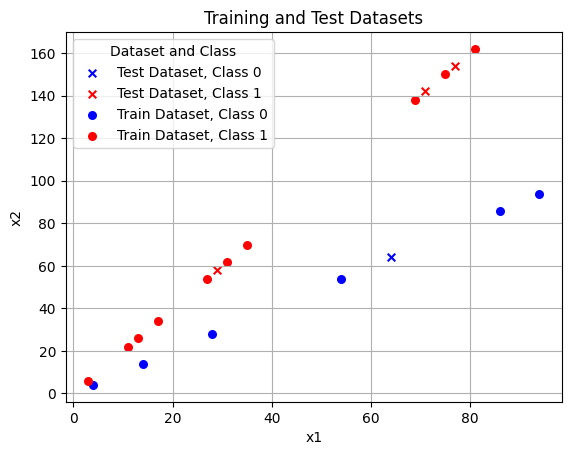

In [2]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_datasets(train_dataset, test_dataset):
    # Combine datasets into a DataFrame for easier handling
    train_df = pd.DataFrame(train_dataset, columns=["x1", "x2", "class"])
    train_df["set"] = "Train"

    test_df = pd.DataFrame(test_dataset, columns=["x1", "x2", "class"])
    test_df["set"] = "Test"

    combined_df = pd.concat([train_df, test_df], ignore_index=True)

    # Define colors and markers
    colors = {0: "blue", 1: "red"}
    markers = {"Train": "o", "Test": "x"}

    # Plot each group using Matplotlib
    fig, ax = plt.subplots()
    for (dataset, cls), group in combined_df.groupby(["set", "class"]):
        ax.scatter(
            group["x1"],
            group["x2"],
            color=colors[cls],
            label=f"{dataset} Dataset, Class {cls}",
            s=30,
            marker=markers[dataset],
        )

    # Manage legend and labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Dataset and Class", loc="best")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title("Training and Test Datasets")
    ax.grid(True)


plot_datasets(dataset_train, dataset_test)
plt.show()

## Defining a Linear Classifier

With our dataset prepared, we now turn to the mathematical foundation that enables our model to classify an input $x_{1} \text{and} x_{2}$ as belonging to classes $0$ or $1$, as follows:

$
c: \mathbb{N} \to \{0,1\}, \quad
c(x_{1},x_{2}) =
\begin{cases} 
1, & \text{if } (x_{1},x_{2}) \in \text{Class 1}, \\
0, & \text{if } (x_{1},x_{2}) \in \text{Class 2}.
\end{cases}
$

This classification can be achieved by using the algebraic representation of a line in a Cartesian coordinate system, described by:

$
z(x) = w_{1}x_{1}+w_{2}x_{2} + c,
$

where:
- $w_{1} text{ and } w_{2}$ represent the weights that determine the slope representing the angle of the resulting line relative to the $x$-axis,
- $c$ is the intercept, indicating where the line intersects the $y$-axis.

From the plotted graph above, it becomes clear that the two classes are linearly separable, which makes the use of a linear separation boundary where $w_{1} \text{ and } w_{2}$ are trained using Rosenblatt's Perceptron algorithm appropriate.

To drive this point home, here's how a line defined by $w_{1}=1, w_{2}=0.5, \text{ and } c=0$ would look like plotted on our previous image.

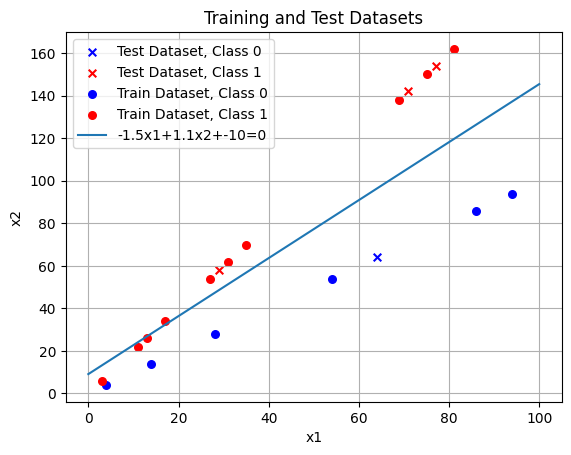

In [3]:
zx = lambda x1, x2, w1, w2, c: w1 * x1 + w2 * x2 + c


def plot_zx(w1, w2, c):
    x2 = lambda x1: (
        (-w1 * x1 - c) / w2 if w2 != 0 else -c / w1 if w1 != 0 else c
    )  # this is because the equation of the line is w1*x1 + w2*x2 + c = 0, hence x2 = (-w1*x1 - c) / w2
    x1_values = range(0, 101)
    x2_values = [x2(x1) for x1 in x1_values]
    plt.plot(x1_values, x2_values, label=f"{w1}x1+{w2}x2+{c}=0")
    plt.legend(loc="best")


def plot_datasets_and_zx(w1, w2, c):
    plot_datasets(dataset_train, dataset_test)
    plot_zx(w1, w2, c)


plot_datasets_and_zx(-1.5, 1.1, -10)

Now, it is obvious that in this configuration the datapoints are seperated neatly. There are, however, alternative ways to configure $w_{1},\ w_{2}, \text{ and } c$ to achieve less ideal examples. For example, when $w_{1}=0.1,\ w_{2}=0.1, \text{ and } c=0.5$, we gen a less ideal separation boundary.

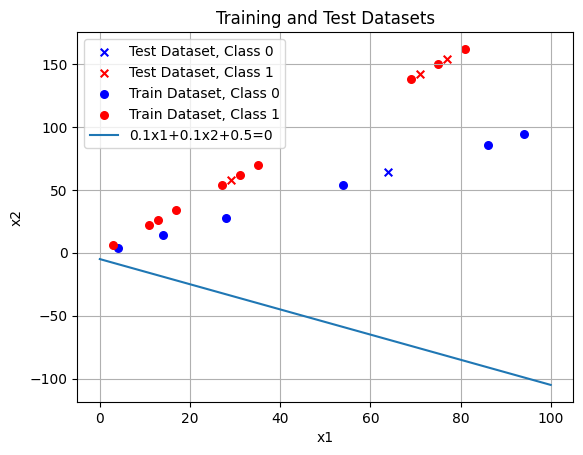

In [4]:
plot_datasets_and_zx(0.1, 0.1, 0.5)

In this particular case, $z$ will not help classifying any data points.

## Evaluating the performance of the classifier

Now that we defined $z=w_{1}x_{1}+w_{2}x_{2}+c$ as our classifier's decision boundary, and that we established visually that it works for some hand-picked values (among probably other options), let's define a computational approach to determine its performance, using a so-called _accuracy_ metric.

### Defining the classifier

But before we delve into the performance of our classifier, let's actually define it as follows:

$
c: \mathbb{N} \to \{0,1\}, \quad
c(x_{1},x_{2}) =
\begin{cases} 
1, & \text{if } z(x_{1},x_{2}) >= 0, \\
0, & \text{if } z(x_{1},x_{2}) <0.
\end{cases}
$

In essence, this means that if a number $x$ is above the decision boundary defined by $f(x)$, it will be classified as $1$, otherwise $0$.

Let's implement the classifier in code and then get back to the discussion about evaluating its pefromance.


In [5]:
cx = lambda x1, x2, w1, w2, c: 1 if zx(x1, x2, w1, w2, c) >= 0 else 0


def accuracy(dataset, w1, w2, c):
    print(f"Calculating accuracy on training set using w1={w1}, w2={w2}, c={c}")
    correct = 0
    for x1, x2, y in dataset:
        if y == cx(x1, x2, w1, w2, c):
            correct += 1
    print(
        f"Resulting accuracy: {correct}/{len(dataset)}, or {correct/len(dataset)*100:.2f}%"
    )
    return correct / len(dataset)


# Applying the accuracy function to the training set using the two sets of weights and bias as shown above, in the first example
accuracy(dataset_train, -1.5, 1.1, -10)

# Applying the accuracy function to the training set using two sets of weights and bias as shown above, in the second example
accuracy(dataset_train, 0.1, 0.1, 0.5)

Calculating accuracy on training set using w1=-1.5, w2=1.1, c=-10
Resulting accuracy: 13/16, or 81.25%
Calculating accuracy on training set using w1=0.1, w2=0.1, c=0.5
Resulting accuracy: 10/16, or 62.50%


0.625

### Discussion on Accuracy

As shown earlier, varying weights and bias values yield different accuracy results. This is because distinct weights and biases establish unique decision boundaries that can perform differently depending on how well they "classify" the dataset into correct classes. The challenge lies in finding the "optimal" values for these two parameters. To achieve this, we employ a process known as _model training_.

## Model Training

Using the insights gained from our analysis, we will now proceed to train our model through a series of iterations, refining the weights and bias values until we reach an acceptable level of accuracy. This iterative process enables us to find the ideal combination of parameters that best suit our dataset and classification task.

In [6]:
# First, let's initialize the weights and bias to zero
w1, w2, c = 0, 0, 0

# Let's now define the learning rate
learning_rate = 0.1

# Let's now define the number of epochs
num_epochs = 5

# Create a DataFrame to store the details of the epochs
epoch_data = []

# Let's now start the training loop
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}")
    error = 0
    for x1, x2, y in dataset_train:
        z = zx(x1, x2, w1, w2, c)
        y_hat = 1 if z >= 0 else 0
        if y != y_hat:
            error += 1 # Count the number of errors
        w1 += learning_rate * (y - y_hat) * x1
        w2 += learning_rate * (y - y_hat) * x2
        c += learning_rate * (y - y_hat)
        print(f"  x1={x1}, x2={x2}, y={y}, z={z:.2f}, y_hat={y_hat}, w1={w1:.2f}, w2={w2:.2f}, c={c:.2f}")
        # Append the details to the DataFrame
    epoch_data.append({
        "epoch": epoch + 1,
        "x1": x1,
        "x2": x2,
        "y": y,
        "z": z,
        "y_hat": y_hat,
        "w1": w1,
        "w2": w2,
        "c": c,
        "err": error
    })
epoch_details = pd.DataFrame(epoch_data)
# Display the DataFrame
epoch_details.head()

Epoch 1
  x1=81, x2=162, y=1, z=0.00, y_hat=1, w1=0.00, w2=0.00, c=0.00
  x1=14, x2=14, y=0, z=0.00, y_hat=1, w1=-1.40, w2=-1.40, c=-0.10
  x1=3, x2=6, y=1, z=-12.70, y_hat=0, w1=-1.10, w2=-0.80, c=0.00
  x1=94, x2=94, y=0, z=-178.60, y_hat=0, w1=-1.10, w2=-0.80, c=0.00
  x1=35, x2=70, y=1, z=-94.50, y_hat=0, w1=2.40, w2=6.20, c=0.10
  x1=31, x2=62, y=1, z=458.90, y_hat=1, w1=2.40, w2=6.20, c=0.10
  x1=28, x2=28, y=0, z=240.90, y_hat=1, w1=-0.40, w2=3.40, c=0.00
  x1=17, x2=34, y=1, z=108.80, y_hat=1, w1=-0.40, w2=3.40, c=0.00
  x1=13, x2=26, y=1, z=83.20, y_hat=1, w1=-0.40, w2=3.40, c=0.00
  x1=86, x2=86, y=0, z=258.00, y_hat=1, w1=-9.00, w2=-5.20, c=-0.10
  x1=69, x2=138, y=1, z=-1338.70, y_hat=0, w1=-2.10, w2=8.60, c=0.00
  x1=11, x2=22, y=1, z=166.10, y_hat=1, w1=-2.10, w2=8.60, c=0.00
  x1=75, x2=150, y=1, z=1132.50, y_hat=1, w1=-2.10, w2=8.60, c=0.00
  x1=54, x2=54, y=0, z=351.00, y_hat=1, w1=-7.50, w2=3.20, c=-0.10
  x1=4, x2=4, y=0, z=-17.30, y_hat=0, w1=-7.50, w2=3.20, c=-0.10

,epoch,x1,x2,y,z,y_hat,w1,w2,c,err
0,1,27,54,1,-29.8,0,-4.8,8.6,0.0,8
1,2,27,54,1,124.1,1,-11.8,8.2,-0.1,5
2,3,27,54,1,124.1,1,-11.8,8.2,-0.1,0
3,4,27,54,1,124.1,1,-11.8,8.2,-0.1,0
4,5,27,54,1,124.1,1,-11.8,8.2,-0.1,0


### Interpreting the Results
Now that we have the results, let's interpret them. Observe the changes in weights $w_1, w_2$ and the bias $c$ across epochs. These updates reflect the model's learning to classify data points accurately. The weights and bias are adjusted iteratively to minimize classification errors, improving the predictive accuracy of the model over time.

We keep track of the number of misclassified points in each epoch to understand how the model is learning. You can follow the evolution of the misclassified points by following the `err` column in the table (dataframe) above. As the epochs progress, the number of misclassifications decreases, indicating that the model is getting better at classifying the dataset. Actually, by the end of the 2nd epoch, the model has learned to classify all the points correctly.

## Visualizing the Decision Boundary
With the final learned weights and bias, we can visualize the decision boundary. This boundary is represented by the line defined by the equation $z = w_{1}x_{1} + w_{2}x_{2} + c$. By plotting this line, you can see how the model classifies the dataset and separates the two classes. Below is an interactive plot that allows you to visualize how changes in the weights and bias influence the decision boundary. 


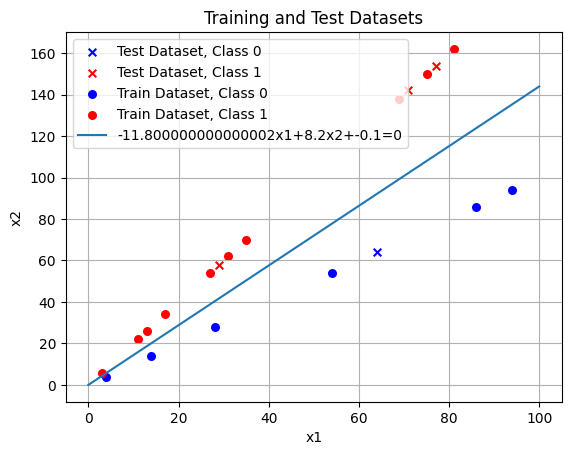

In [7]:
plot_datasets_and_zx(w1, w2, c)

As we can see, the decision boundary separates the two classes in the dataset. This means that the model has learned to classify the data points based on the values of $w_{1}, w_{2}$, and $c$. Cool, right?

## Interactive Visualization
Now, to drive this knowledge home, let's create an interactive visualization to see how the decision boundary changes as we adjust the weights and bias. This will help us understand how the model classifies the data points and separates the two classes.

In [9]:
pip install ipywidgets


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   -- ------------------------------------- 10.2/139.8 kB ? eta -:--:--
   -- ------------------------------------- 10.2/139.8 kB ? eta -:--:--
   -------- ------------------------------ 30.7/139.8 kB 217.9 kB/s eta 0:00:01
   ----------- --------------------------- 41.0/139.8 kB 217.9 kB/s eta 0:00:01
   -------------------- ------------------ 71.7/139.8 kB 280.5 kB/s eta 0:00:01
   ------------------------------------ - 133.1/139.8 kB 462.0 kB/s eta 0:00:01
   -------------------------------------- 139.8/139.8 kB 436.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/214.4 kB ? eta -:--:--
   ----------------- ---------------------- 92.2/214.4 kB 2.6 MB/s eta 0:00:01
   -------------------------- ------------- 143.4/214.4 kB 1.7 MB/s eta 0:00:01
   ---


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from ipywidgets import interact

trained_w1 = w1
trained_w2 = w2
trained_c = c
print(f"Trained weights: w1={trained_w1}, w2={trained_w2}, c={trained_c}")

def plot_dynamic_line(w1=trained_w1, w2=trained_w2, c=trained_c):
    plot_datasets(dataset_train, dataset_test)
    plot_zx(w1, w2, c)

# This will display an interactive plot that allows you to change the weights and bias. The default values are the trained weights and bias.
interact(plot_dynamic_line, w1=(-20, 20, 0.5), w2=(-20, 20, 0.5), c=(-50, 50, 0.5))

Trained weights: w1=-11.800000000000002, w2=8.2, c=-0.1


Play with the "knobs" $w_{1}, w_{2}$, and $c$ to see how the decision boundary changes. You can observe how the line moves and rotates as you adjust the weights and bias. This interactive visualization provides an intuitive way to understand how the model works and how the decision boundary is determined by the weights and bias values.

# Conclusion
In this notebook, we have implemented a simple perceptron model to classify a linearly separable dataset. We have generated a dataset, visualized it, defined a linear classifier, evaluated its performance, and trained the model to find the optimal weights and bias values. The model has been trained through a series of iterations, refining the parameters until an acceptable level of accuracy has been achieved. The results have been interpreted, and the model has been evaluated based on its performance. What we can see is that the `err` value has decreased over time, which means that the model has learned to classify the data points correctly. If we take a look, it managed to do so by the end of the 2nd epoch. Impressive, right?

## Limitations and Future Work
While the perceptron model is a powerful tool for classifying linearly separable datasets, it has its limitations. For example, the model may not perform well on datasets that are not linearly separable. In future work, we could explore more advanced models, such as neural networks, to classify more complex datasets. We could also experiment with different activation functions, loss functions, and optimization algorithms to improve the performance of the model.

Here are the advancements in neural networks that we could explore in future work:
- Implementing the Adaptive Linear Neuron (Adaline) model, which uses a continuous linear activation function.
- Implementing the logistic regression model, which uses a sigmoid activation function.
- Implementing a multi-layer perceptron (MLP) to classify non-linearly separable datasets.
- Implementing a convolutional neural network (CNN) to classify image datasets.
- Implementing a recurrent neural network (RNN) to classify sequential data.
- Implementing a generative adversarial network (GAN) to generate new data samples.
- Implementing a transformer model to perform natural language processing tasks in its three variants: encoder-only, decoder-only, and encoder-decoder.

Plenty of work to do, so stay tuned for more exciting projects in the future!